# 🧠 Building Micrograd from Scratch
### A step-by-step implementation of an autograd engine and backpropagation

In this notebook, I build a mini deep learning engine from scratch — inspired by how frameworks like PyTorch work internally.

Instead of using high-level libraries, I:
- Build an **automatic differentiation (autograd) engine**
- Implement **backpropagation manually**
- Create a small **neural network (MLP)**
- Train it using **gradient descent**

> 📌 Based on Andrej Karpathy's [micrograd lecture](https://www.youtube.com/watch?v=VMj-3S1tku0)

## 🎯 Why Build This From Scratch?

Modern frameworks like PyTorch hide the complexity of training neural networks behind clean APIs.

But under the hood:
- Neural networks are just **mathematical expressions**
- Backpropagation applies the **chain rule** from calculus
- Gradients flow backward through a **computational graph**

Building everything from scratch makes all of this concrete and visible.

## 🔹 What is Micrograd?

Micrograd is a tiny autograd engine that implements backpropagation over a dynamically built computational graph.

It works by:
- Representing every computation as a **node in a graph**
- **Tracking which operation** produced each value
- Computing gradients using **reverse-mode automatic differentiation**

Even though it operates on scalar values only, it is powerful enough to build and train full neural networks.

In [6]:
# Importing necessary libraries
import numpy as np
import math
import matplotlib.pyplot as plt
import random

## 🔹 Step 1: Building the Value Object

A neural network is just a mathematical expression — it takes data as input, performs operations, and produces an output.

Micrograd is a **scalar-level autograd engine**. It tracks every operation so that gradients can be computed automatically during backpropagation.

We start by building a `Value` class that:
- Stores a **number** (`data`)
- Stores its **gradient** (`grad`)
- Tracks **which operation** created it (`_op`)
- Remembers its **parent nodes** (`_prev`) for backpropagation

Each operation like `+` or `*` creates a new `Value` and links it back to its inputs — automatically building the computational graph.

In [7]:
class Value:
    def __init__(self, data):
        self.data = data  # The actual number this node holds, e.g. 2.0
    
    def __repr__(self):
        # Controls what prints when you do print(a) or just type 'a' in a cell
        # Without this, Python would print something unhelpful like <__main__.Value object at 0x...>
        return f"Value(data={self.data})"

# Quick check — should print Value(data=2.0)
a = Value(2.0)
print(a)

Value(data=2.0)


## ➕ Adding Arithmetic Operations

Now we add `+` and `*` to the `Value` class so we can build expressions.

We also start tracking:
- `_prev` — which Values produced this one (the children)
- `_op` — which operation was used

This is what allows us to reconstruct the full computational graph later.

In [8]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data          # The number stored in this node
        self.grad = 0.0           # Gradient starts at 0 — we assume no influence until backprop runs
        self._prev = set(_children)  # Set of parent nodes that produced this value
                                     # Using a set (not list) for fast lookup and to avoid duplicates
        self._op = _op            # Which operation created this node — used in visualization
        self.label = label        # Optional human-readable name e.g. 'x1', 'w1'

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        # Creates a new Value node representing self + other
        # Passes (self, other) as children so we can trace back through the graph
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        # Same idea as __add__ but for multiplication
        out = Value(self.data * other.data, (self, other), '*')
        return out

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
print(d)
print("Children of d:", d._prev)   # Should show the two Value nodes that produced d
print("Operation that produced d:", d._op)  # Should show '+'

Value(data=4.0)
Children of d: {Value(data=10.0), Value(data=-6.0)}
Operation that produced d: +


## 🔍 Visualizing the Computational Graph

Before we do backpropagation, it helps to *see* the graph we're building.

We use **Graphviz** to draw each Value as a node, and each operation as an edge connecting inputs to outputs.

> Note: The `trace` and `draw_dot` functions below are utility code — their purpose is visualization only, not part of the core autograd engine.

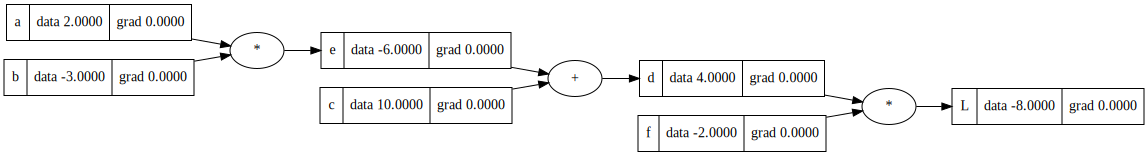

In [9]:
from graphviz import Digraph

def trace(root):
    # Recursively walks the graph starting from the output node (root)
    # and collects every node and every edge into two sets
    nodes, edges = set(), set()
    
    def build(v):
        if v not in nodes:          # Only visit each node once to avoid infinite loops
            nodes.add(v)
            for child in v._prev:   # Walk backwards through parent nodes
                edges.add((child, v))  # Edge goes from child (input) → v (output)
                build(child)           # Recurse into the child
    
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = draw graph left to right
    nodes, edges = trace(root)
    
    for n in nodes:
        uid = str(id(n))  # Unique identifier for each node using Python's object id
        
        # Draw a rectangular box for each Value node showing its label, data, and gradient
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        
        if n._op:
            # If this node was created by an operation, draw a small circle for that operation
            # e.g. a '+' node that sits between the inputs and the output
            dot.node(name=uid + n._op, label=n._op)
            # Connect the operation node to the Value node it produced
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # Connect each input Value node to the operation node that consumed it
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

# Building an expression to visualize
# L = (a * b + c) * f
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

# All grads show 0.0 here — backprop hasn't run yet
draw_dot(L)

## ↩️ Step 2: Backpropagation

The diagram above shows the **forward pass** — how values flow left to right to produce the output `L`.

Now we run **backpropagation** — starting from `L` and working backwards to compute how much each input contributed to the output.

For every node in the graph, we want to compute:

$$\frac{\partial L}{\partial \text{node}}$$

This tells us how sensitive the output `L` is to each value — which is exactly what we need to train a neural network.

## 📐 Manually Computing Gradients

Before automating this, let's verify gradients by **numerical estimation** — nudging each variable by a tiny amount `h` and seeing how much `L` changes.

This is the definition of a derivative:

$$\frac{df}{dx} \approx \frac{f(x+h) - f(x)}{h}$$

In [21]:
def estimate_gradients_numerically():
    # h is a tiny nudge we add to each variable one at a time
    # Small enough to approximate a derivative, large enough to avoid floating point noise
    h = 0.001

    # First, compute the base output L without any nudging
    a = Value(2.0); b = Value(-3.0); c = Value(10.0)
    e = a * b; d = e + c; f = Value(-2.0); L = d * f
    L1 = L.data  # This is our baseline

    # Gradient of a:
    # Nudge only a by h, recompute L, measure how much L changed
    # (L2 - L1) / h approximates dL/da
    a = Value(2.0); a.data += h
    b = Value(-3.0); c = Value(10.0)
    e = a * b; d = e + c; f = Value(-2.0); L = d * f
    a_grad_numerical = (L.data - L1) / h

    # Gradient of b: same idea, nudge only b this time
    a = Value(2.0); b = Value(-3.0); b.data += h
    c = Value(10.0)
    e = a * b; d = e + c; f = Value(-2.0); L = d * f
    b_grad_numerical = (L.data - L1) / h

    # Gradient of f: nudge only f
    a = Value(2.0); b = Value(-3.0); c = Value(10.0)
    e = a * b; d = e + c; f = Value(-2.0); f.data += h; L = d * f
    f_grad_numerical = (L.data - L1) / h

    print(f"Numerical gradient of a: {a_grad_numerical:.4f}")
    print(f"Numerical gradient of b: {b_grad_numerical:.4f}")
    print(f"Numerical gradient of f: {f_grad_numerical:.4f}")
    print("\nWe will verify these against our autograd engine after we build it.")
    
    return a_grad_numerical, b_grad_numerical, f_grad_numerical

numerical_grads = estimate_gradients_numerically()

Numerical gradient of a: 6.0000
Numerical gradient of b: -4.0000
Numerical gradient of f: 4.0000

We will verify these against our autograd engine after we build it.


## 🧬 Step 3: Manual Backpropagation Through a Neuron

A neural network is made of **layers of neurons**. A single neuron:

1. Takes inputs `x1, x2, ...`
2. Multiplies each by a weight `w1, w2, ...`
3. Adds a bias `b`
4. Passes the result through an **activation function**

The activation function squashes the output to a fixed range. We use **tanh** here, which squashes values to `[-1, 1]`.

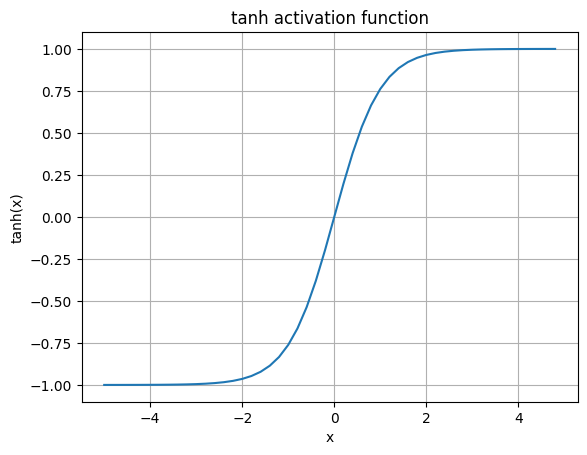

In [22]:
# Visualizing the tanh activation function
x = np.arange(-5, 5, 0.2)
plt.plot(x, np.tanh(x))
plt.title("tanh activation function")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.grid()
plt.show()

## ⚙️ Step 4: Automating Backpropagation with `_backward`

Instead of computing gradients manually, we define a `_backward` function inside each operation.

Each `_backward`:
- Knows the **local derivative** of its operation
- Multiplies it by the **incoming gradient** (chain rule)
- Accumulates the result using `+=` into the input's `.grad`

We use `+=` instead of `=` to correctly handle cases where a variable appears more than once in an expression — otherwise we would overwrite its gradient instead of accumulating contributions from all paths.

In [24]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data          # The actual number this node holds
        self.grad = 0.0           # Gradient of the loss w.r.t. this value (starts at 0)
        self._backward = lambda: None  # Will be overwritten by each operation to store its gradient formula
        self._prev = set(_children)   # Parent nodes that produced this value
        self._op = _op            # The operation that created this node e.g. '+', '*', 'tanh'
        self.label = label        # Optional name for visualization

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            # Using += not = because a variable can appear multiple times in an expression
            # e.g. a + a — both self and other point to the same object
            # If we used =, the second write would overwrite the first, giving wrong gradients
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            # Derivative of multiplication: each input's gradient = the other input's value * output gradient
            # This is the product rule / chain rule applied to x*y
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only int/float powers supported"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            # Power rule: d/dx(x^n) = n * x^(n-1)
            # Multiplied by out.grad to apply the chain rule
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        # Handles cases like 2 * a where Python tries int.__mul__(Value) and fails
        # Python then falls back to Value.__rmul__, which we redirect to our own __mul__
        return self * other

    def __radd__(self, other):
        # Same idea as __rmul__ but for addition: handles 2 + a
        return self + other

    def __truediv__(self, other):
        # Division as multiplication by inverse: a/b = a * b^(-1)
        # More general than implementing division separately
        return self * other ** -1

    def __neg__(self):
        # Negation: flips the sign by multiplying by -1
        return self * -1

    def __sub__(self, other):
        # Subtraction: a - b = a + (-b)
        return self + (-other)

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            # Derivative of e^x is e^x itself — which is already stored in out.data
            # Multiplied by out.grad for chain rule
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)  # tanh formula
        out = Value(t, (self,), 'tanh')

        def _backward():
            # Derivative of tanh(x) = 1 - tanh(x)^2
            # t is already the forward pass result, so we reuse it here
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # Step 1: Build topological order — ensures every node is processed
        # only after all nodes that depend on it have already been processed
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)  # Append after visiting all children = leaves come first
        build_topo(self)

        # Step 2: Seed the gradient of the output node as 1.0
        # dL/dL = 1 by definition — gradient of output with respect to itself
        self.grad = 1.0

        # Step 3: Walk the graph in reverse topological order (output → inputs)
        # and let each node propagate its gradient to its children
        for node in reversed(topo):
            node._backward()

## ✅ Verifying Our Autograd Engine

Earlier we computed gradients numerically by nudging each variable.

Now that our autograd engine is built, let's run the same expression through it and confirm both approaches give the same answer.

If they match — our `_backward` functions are correctly implementing the chain rule.

In [26]:
# Run the same expression through our autograd engine
a = Value(2.0, label='a'); b = Value(-3.0, label='b')
c = Value(10.0, label='c'); f = Value(-2.0, label='f')
e = a * b; d = e + c; L = d * f
L.backward()  # Our engine computes all gradients automatically

# Compare against numerical estimates computed earlier
print(f"{'Parameter':<12} {'Numerical':>12} {'Our Autograd':>14} {'Match?':>10}")
print("-" * 52)
comparisons = [
    ("a", numerical_grads[0], a.grad),
    ("b", numerical_grads[1], b.grad),
    ("f", numerical_grads[2], f.grad),
]
for name, numerical, autograd in comparisons:
    match = "✅" if abs(numerical - autograd) < 1e-3 else "❌"
    print(f"{name:<12} {numerical:>12.6f} {autograd:>14.6f} {match:>10}")

Parameter       Numerical   Our Autograd     Match?
----------------------------------------------------
a                6.000000       6.000000          ✅
b               -4.000000      -4.000000          ✅
f                4.000000       4.000000          ✅


## 🧬 Step 5: Backpropagation Through a Neuron

Now let's apply our engine to a real neuron expression:

$$o = \tanh(x_1 w_1 + x_2 w_2 + b)$$

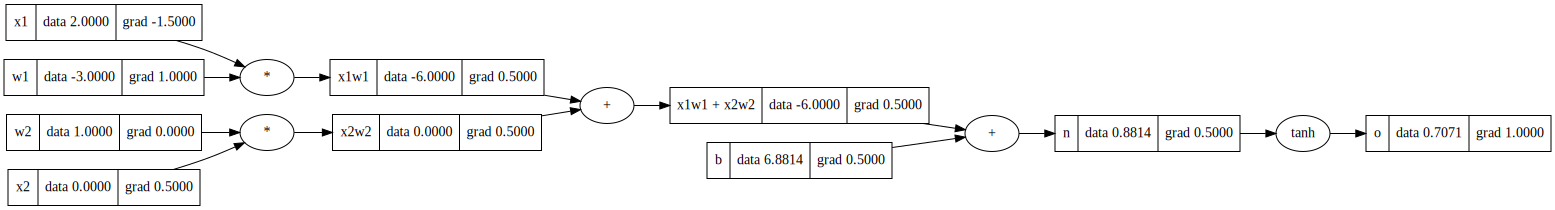

In [27]:
# A single neuron computes: output = tanh(x1*w1 + x2*w2 + b)
# x1, x2 are the inputs coming into the neuron (like pixel values or features)
# w1, w2 are the weights — these are what the network learns
# b is the bias — lets the neuron shift its output independently of inputs

x1 = Value(2.0, label='x1')   # Input 1
x2 = Value(0.0, label='x2')   # Input 2 (zero here, so x2*w2 will contribute nothing)
w1 = Value(-3.0, label='w1')  # Weight for input 1
w2 = Value(1.0, label='w2')   # Weight for input 2
b  = Value(6.8813735870195432, label='b')  # Bias — chosen so tanh output is a clean number

# Step 1: multiply each input by its weight
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'

# Step 2: sum the weighted inputs
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'

# Step 3: add bias
n = x1w1x2w2 + b; n.label = 'n'

# Step 4: pass through tanh activation — squashes output to [-1, 1]
o = n.tanh(); o.label = 'o'

# Run backpropagation — computes gradients for all nodes
o.backward()

# The graph now shows gradients filled in for every node
# w1.grad tells us: if w1 increases slightly, how much does the output change?
draw_dot(o)

## 🔬 Breaking tanh Into Primitive Operations

`tanh` can also be expressed entirely using `exp`, `-`, `+`, and `/`:

$$\tanh(x) = \frac{e^{2x} - 1}{e^{2x} + 1}$$

This shows that micrograd doesn't need `tanh` built-in — it emerges naturally from simpler operations. The gradients flow correctly either way.

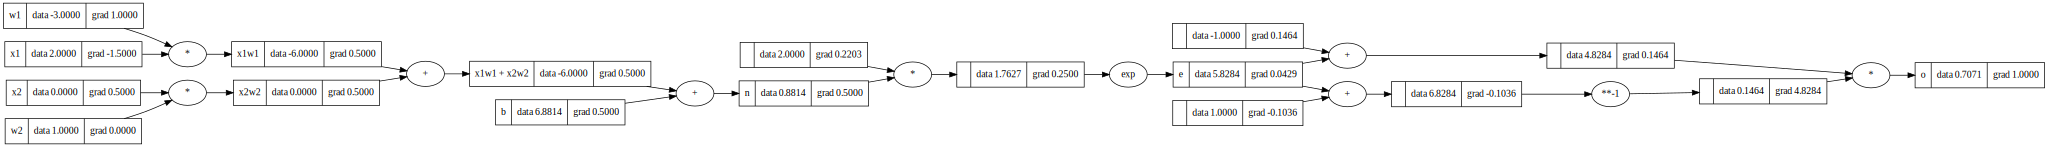

In [29]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b  = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

# Computing tanh manually using primitive ops
# This shows micrograd doesn't need tanh built-in — it emerges from simpler operations
# The graph will be deeper but gradients will be identical to the tanh version above
e = (2 * n).exp(); e.label = 'e'       # e = e^(2n)
o = (e - 1) / (e + 1); o.label = 'o'  # o = (e-1)/(e+1) = tanh(n)

o.backward()
draw_dot(o)

## 🔥 Step 6: Verification — Side-by-Side Comparison with PyTorch

Let's run the exact same single-neuron expression in both our micrograd engine and PyTorch, then compare gradients directly.

If our implementation is correct, they should match to many decimal places.

PyTorch requires:
- **`.double()`** — casts to float64 to match Python's default float precision
- **`requires_grad=True`** — tells PyTorch this is a learnable parameter that needs a gradient (leaf nodes don't get gradients by default)

In [30]:
import torch

# ── Our micrograd ─────────────────────────────────────────────
x1_mg = Value(2.0, label='x1')
x2_mg = Value(0.0, label='x2')
w1_mg = Value(-3.0, label='w1')
w2_mg = Value(1.0, label='w2')
b_mg  = Value(6.8813735870195432, label='b')

x1w1 = x1_mg * w1_mg; x1w1.label = 'x1w1'
x2w2 = x2_mg * w2_mg; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n_mg = x1w1x2w2 + b_mg; n_mg.label = 'n'
o_mg = n_mg.tanh(); o_mg.label = 'o'
o_mg.backward()  # Run our backprop

# ── PyTorch ───────────────────────────────────────────────────
x1_pt = torch.Tensor([2.0]).double();             x1_pt.requires_grad = True
x2_pt = torch.Tensor([0.0]).double();             x2_pt.requires_grad = True
w1_pt = torch.Tensor([-3.0]).double();            w1_pt.requires_grad = True
w2_pt = torch.Tensor([1.0]).double();             w2_pt.requires_grad = True
b_pt  = torch.Tensor([6.8813735870195432]).double(); b_pt.requires_grad = True

n_pt = x1_pt*w1_pt + x2_pt*w2_pt + b_pt
o_pt = torch.tanh(n_pt)
o_pt.backward()  # Run PyTorch backprop

# ── Side-by-side comparison ───────────────────────────────────
print(f"{'Parameter':<12} {'Micrograd':>12} {'PyTorch':>12} {'Match?':>10}")
print("-" * 50)

params = [
    ("x1", x1_mg.grad, x1_pt.grad.item()),
    ("x2", x2_mg.grad, x2_pt.grad.item()),
    ("w1", w1_mg.grad, w1_pt.grad.item()),
    ("w2", w2_mg.grad, w2_pt.grad.item()),
    ("b",  b_mg.grad,  b_pt.grad.item()),
]

for name, mg_grad, pt_grad in params:
    match = "✅" if abs(mg_grad - pt_grad) < 1e-6 else "❌"
    print(f"{name:<12} {mg_grad:>12.6f} {pt_grad:>12.6f} {match:>10}")

Parameter       Micrograd      PyTorch     Match?
--------------------------------------------------
x1              -1.500000    -1.500000          ✅
x2               0.500000     0.500000          ✅
w1               1.000000     1.000000          ✅
w2               0.000000     0.000000          ✅
b                0.500000     0.500000          ✅


## 🏗️ Step 7: Building a Neural Network

Now that we have a working autograd engine, we can use it to build actual neural networks.

We build three classes on top of `Value`:

- **`Neuron`** — a single unit with weights, bias, and tanh activation
- **`Layer`** — a collection of neurons that all receive the same inputs
- **`MLP`** (Multi-Layer Perceptron) — a stack of layers forming a complete network

This is exactly how PyTorch's `nn.Module` works — just at a much higher level.

In [31]:
class Neuron:
    def __init__(self, nin):
        # nin: number of inputs this neuron receives
        # Each input gets its own weight, initialized randomly between -1 and 1
        # Random initialization breaks symmetry — if all weights were 0, all neurons would learn the same thing
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))  # One bias per neuron

    def __call__(self, x):
        # Forward pass through a single neuron
        # zip(self.w, x) pairs each weight with its corresponding input
        # sum(..., self.b) starts the sum from self.b instead of 0
        # This is important — starting from Value(0.0) would also work but adds an unnecessary node
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)

        # Pass through tanh activation to squash output between -1 and 1
        # Without activation, stacking layers is pointless — the whole network collapses to a linear function
        return act.tanh()

    def parameters(self):
        # Returns all learnable parameters of this neuron: weights + bias
        # Used by the training loop to update all parameters at once
        return self.w + [self.b]  # [self.b] wraps bias in a list so we can concatenate with self.w


class Layer:
    def __init__(self, nin, nout):
        # nin: number of inputs coming into this layer
        # nout: number of neurons in this layer (= number of outputs)
        # Each neuron in this layer receives ALL nin inputs independently
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        # Run all neurons in this layer on the same input x
        outs = [n(x) for n in self.neurons]

        # If there's only one output neuron (e.g. final output layer),
        # return the value directly instead of a list — cleaner for loss computation
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        # Collect parameters from every neuron in this layer
        # Flat list: [w0, w1, b, w0, w1, b, ...] for all neurons
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
    def __init__(self, nin, nouts):
        # nin: number of inputs to the network
        # nouts: list defining the size of each layer e.g. [4, 4, 1]
        #   means: hidden layer of 4, hidden layer of 4, output layer of 1

        # sz builds the full size sequence: [nin, 4, 4, 1]
        # so Layer(sz[0], sz[1]) = Layer(3, 4), Layer(sz[1], sz[2]) = Layer(4, 4), etc.
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        # Pass input through each layer sequentially
        # Output of one layer becomes input to the next
        for layer in self.layers:
            x = layer(x)
        return x  # Final output after passing through all layers

    def parameters(self):
        # Collect every parameter across all layers — used by the training loop
        return [p for layer in self.layers for p in layer.parameters()]


# Quick test — build a network with 3 inputs, two hidden layers of 4, one output
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
print("Output:", n(x))
print("Total parameters:", len(n.parameters()))  # Should be 41

Output: Value(data=0.6924661510873761)
Total parameters: 41


## 📊 Step 8: A Small Binary Classification Dataset

We define a tiny dataset with 4 examples and binary targets (`+1` or `-1`).

The goal: train the MLP to predict the correct target for each input.

In [32]:
# A tiny binary classification dataset — 4 examples, each with 3 features
# In a real problem these might be measurements, pixel values, sensor readings, etc.
xs = [
    [2.0,  3.0, -1.0],   # Example 1 → should output +1
    [3.0, -1.0,  0.5],   # Example 2 → should output -1
    [0.5,  1.0,  1.0],   # Example 3 → should output -1
    [1.0,  1.0, -1.0],   # Example 4 → should output +1
]

# Desired targets: +1 means "class A", -1 means "class B"
# We use +1/-1 instead of 1/0 because tanh outputs in [-1, 1]
ys = [1.0, -1.0, -1.0, 1.0]

# Forward pass — see where predictions start before any training
ypred = [n(x) for x in xs]
print("Predictions:", [round(y.data, 4) for y in ypred])
print("Targets:    ", ys)
# These will be far off initially — the network has random weights

Predictions: [0.6925, 0.9064, 0.514, 0.7174]
Targets:     [1.0, -1.0, -1.0, 1.0]


## 📉 Step 9: Loss Function — Why MSE?

To train the network, we need a single number that measures how wrong our predictions are. This is the **loss**.

We use **Mean Squared Error (MSE)**:

$$\text{loss} = \sum_{i} (\hat{y}_i - y_i)^2$$

### Why MSE and not Cross-Entropy?

This is a fair question. The short answer: **it depends on the problem**.

| | **MSE** | **Cross-Entropy** |
|---|---|---|
| **Best for** | Regression, continuous targets | Classification with probabilities |
| **Output range** | Any real number | Must be probabilities (0 to 1) |
| **Requires** | Just subtraction | A softmax or sigmoid layer |
| **Our targets** | `+1` and `-1` | Would need `0` and `1` |

Our targets are `+1` and `-1` — real-valued numbers, not probabilities. tanh also naturally outputs in `[-1, 1]`, which aligns perfectly with MSE. Cross-entropy expects outputs to be probabilities between 0 and 1, and targets to be `0` or `1`.

If we were building an image classifier outputting probabilities like "70% cat, 30% dog", **cross-entropy would be the right choice**. For this simple scalar regression task, **MSE is simpler and appropriate**.

> 💡 The loss function is a design choice — it should match the structure of your outputs and targets.

In [33]:
# MSE loss: for each example, square the difference between prediction and target
# Squaring does two things:
#   1. Makes all errors positive (so they don't cancel out)
#   2. Penalizes large errors more heavily than small ones

# sum(..., Value(0.0)) — the second argument is the starting value of the sum
# We use Value(0.0) instead of plain 0 because our + operator expects Value objects
# Without this, Python's built-in sum() would try to do 0 + Value(...) which fails
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))
print("Loss:", loss.data)
# Higher loss = predictions are far from targets
# Our goal: make this number as small as possible through training

Loss: 6.100973544964526


## 🔄 Step 10: Gradient Descent — The Training Loop

Now we put everything together:

1. **Forward pass** — compute predictions and loss
2. **Zero gradients** — reset all `.grad` to `0` before each backward pass
3. **Backward pass** — compute gradients via `loss.backward()`
4. **Update** — nudge each parameter in the direction that reduces loss

The update rule is:

$$p \leftarrow p - \text{lr} \times \frac{\partial \text{loss}}{\partial p}$$

We subtract the gradient because we want to move *downhill* on the loss surface.

> ⚠️ Zeroing gradients before each backward pass is critical. Without it, gradients from previous steps accumulate and corrupt the update — a very common bug in neural net training code.

In [34]:
# Reset the network with fresh random weights to start training from scratch
n = MLP(3, [4, 4, 1])

xs = [
    [2.0,  3.0, -1.0],
    [3.0, -1.0,  0.5],
    [0.5,  1.0,  1.0],
    [1.0,  1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

for k in range(20):
    # ── Step 1: Forward pass ──────────────────────────────────
    # Run every input through the network and compute predictions
    ypred = [n(x) for x in xs]

    # Compute total loss — single number measuring how wrong we are
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))

    # ── Step 2: Zero gradients ────────────────────────────────
    # CRITICAL: reset all gradients to 0 before each backward pass
    # If we don't do this, gradients from the previous step accumulate
    # and corrupt the current update — a very common bug in neural net code
    for p in n.parameters():
        p.grad = 0.0

    # ── Step 3: Backward pass ─────────────────────────────────
    # Compute gradient of loss with respect to every parameter
    # After this, every p.grad tells us: if p increases, does loss go up or down?
    loss.backward()

    # ── Step 4: Update parameters (Gradient Descent) ──────────
    # Move each parameter slightly in the direction that reduces loss
    # We subtract the gradient because we want to go downhill on the loss surface
    # 0.05 is the learning rate — controls how big each step is
    # Too large → overshoots and loss explodes. Too small → learns very slowly
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(f"Step {k:02d} | Loss: {loss.data:.4f}")

Step 00 | Loss: 7.7253
Step 01 | Loss: 1.1479
Step 02 | Loss: 0.4211
Step 03 | Loss: 0.2728
Step 04 | Loss: 0.2030
Step 05 | Loss: 0.1617
Step 06 | Loss: 0.1344
Step 07 | Loss: 0.1149
Step 08 | Loss: 0.1003
Step 09 | Loss: 0.0889
Step 10 | Loss: 0.0798
Step 11 | Loss: 0.0724
Step 12 | Loss: 0.0662
Step 13 | Loss: 0.0610
Step 14 | Loss: 0.0565
Step 15 | Loss: 0.0526
Step 16 | Loss: 0.0492
Step 17 | Loss: 0.0462
Step 18 | Loss: 0.0435
Step 19 | Loss: 0.0412


In [35]:
print("\nFinal Predictions vs Targets:")
print(f"{'Input':<25} {'Predicted':>10} {'Target':>10}")
print("-" * 47)
for x, y in zip(xs, ys):
    pred = n(x).data
    print(f"{str(x):<25} {pred:>10.4f} {y:>10.1f}")


Final Predictions vs Targets:
Input                      Predicted     Target
-----------------------------------------------
[2.0, 3.0, -1.0]              0.9296        1.0
[3.0, -1.0, 0.5]             -0.9128       -1.0
[0.5, 1.0, 1.0]              -0.8853       -1.0
[1.0, 1.0, -1.0]              0.8846        1.0


## ✅ Summary

In this notebook, I built a complete deep learning engine from scratch:

| Component | What it does |
|---|---|
| `Value` | Stores data + gradient, tracks computation graph |
| `_backward` | Computes local gradients using chain rule |
| `backward()` | Runs full backprop via topological sort |
| `Neuron` | Single unit: weighted sum + tanh |
| `Layer` | Collection of neurons |
| `MLP` | Stacked layers forming a full network |
| Training loop | Forward → zero grad → backward → update |

### Key Takeaways

- **Autograd** is just careful bookkeeping of operations and their derivatives
- **Backpropagation** is the chain rule applied recursively over a computation graph
- **Gradient descent** nudges parameters downhill on the loss surface
- PyTorch does all of this under the hood — now we know what's actually happening

> The full source for micrograd is available at [github.com/karpathy/micrograd](https://github.com/karpathy/micrograd)